# PaySim: dòng tiền, financial hubs và cộng đồng giao dịch

**Câu hỏi kinh doanh:** Có thể dùng cấu trúc giao dịch để ưu tiên tài khoản/cụm cần điều tra như thế nào, và PaySim hỗ trợ được đến đâu?
Notebook bắt đầu bằng EDA toàn bộ CSV, sau đó chạy GraphFrames trên một cửa sổ TRANSFER minh bạch để kiểm tra hub, vòng tiền và cộng đồng.
Kết quả là bằng chứng khám phá và giả thuyết điều tra, chưa phải mô hình xác nhận rửa tiền.

**Nguồn:** [Kaggle PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1), [mã nguồn mô phỏng PaySim](https://github.com/EdgarLopezPhD/PaySim).
`isFraud` là nhãn gian lận trong mô phỏng; dữ liệu không có nhãn xác nhận money laundering, KYC, chủ sở hữu hưởng lợi, thiết bị hay địa lý.
Vì vậy, độ chính xác đối với `isFraud` không phải độ chính xác phát hiện rửa tiền.

## 1. Cách chạy và phạm vi phân tích

Mở notebook bằng kernel Python tại `.venv/bin/python`, rồi **Restart Kernel and Run All**.
Môi trường riêng của dự án được đặt trên `/data` qua symlink `.venv`.
Nếu dùng máy khác, cài các gói bên dưới trong môi trường riêng và cung cấp JDK 17/21 đầy đủ qua `JAVA_HOME`.
Bản JDK tại máy này nằm trong `notebook-runtime/jdk` cạnh thư mục dữ liệu và được phát hiện tự động.
Lần khởi động Spark đầu tiên cần Internet để lấy JAR GraphFrames tương ứng.

```bash
python -m pip install pandas pyarrow numpy matplotlib nbformat nbclient ipykernel networkx pyspark==4.0.1 graphframes-py==0.12.2
```

EDA đọc đủ các dòng; đồ thị mặc định dùng TRANSFER trong step 1-24, không chọn theo nhãn gian lận và không lấy ngẫu nhiên từng cạnh.
Cửa sổ ngắn có thể cắt đứt đường đi và làm cụm trông cô lập hơn thực tế.
Đổi `GRAPH_START`, `GRAPH_END`, rồi chạy lại từ đầu để kiểm tra độ nhạy; đặt bằng toàn bộ khoảng step nếu tài nguyên cho phép.
Đọc CSV toàn bộ cần vài GB RAM; Spark chạy sau khi giải phóng DataFrame toàn bộ.


In [1]:
from pathlib import Path
import gc
import os
import sys
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
DATA = ROOT / "data/paysim1/PS_20174392719_1491204439457_log.csv"
assert DATA.is_file(), f"Không tìm thấy {DATA}. Mở notebook từ thư mục graphX."
RUNTIME = DATA.resolve().parent.parent / "notebook-runtime"
RUNTIME.mkdir(parents=True, exist_ok=True)
GRAPH_START, GRAPH_END = 1, 24
GRAPH_TYPES = ("TRANSFER",)
AMOUNT_THRESHOLD = 10_000.0
MAX_CYCLE_HOURS = 24
LPA_ITERATIONS = 5
SEED = 42
assert 1 <= GRAPH_START <= GRAPH_END

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12,
                     "figure.dpi": 110, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("CSV:", DATA.resolve())
print("Python:", sys.version.split()[0])
print({p: metadata.version(p) for p in ["pandas", "pyspark", "graphframes-py"]})


CSV: /data/graphX/paysim1/PS_20174392719_1491204439457_log.csv
Python: 3.13.11
{'pandas': '3.0.2', 'pyspark': '4.0.1', 'graphframes-py': '0.12.2'}


## 2. Đơn vị quan sát và ý nghĩa kinh tế

Mỗi dòng là một **sự kiện giao dịch**, không phải một khách hàng hay một khoản tiền độc lập xuyên suốt chuỗi.
Tổng `amount` là giá trị giao dịch gộp; cùng một dòng tiền có thể được tính nhiều lần khi chuyển qua nhiều chặng.
Đơn vị tiền tệ không được xác nhận trong CSV, nên không tự gắn USD hoặc VND.

| Trường / loại | Cách đọc trong phân tích |
|---|---|
| `step` | Giờ mô phỏng; không có ngày lịch hay thứ tự chính xác trong cùng giờ. |
| `nameOrig`, `nameDest` | ID đầu gửi/nhận theo bản ghi; phải kiểm tra độ lặp trước khi coi là lịch sử tài khoản. |
| `TRANSFER` | Chuyển tiền giữa tài khoản; phù hợp nhất để tìm vòng tiền có hướng. |
| `CASH_OUT` | Rút tiền; liên kết với TRANSFER có thể gợi ý đường thoát ra tiền mặt. |
| `CASH_IN` | Nạp tiền; chiều thay đổi số dư origin khác giao dịch chi ra. Không gộp máy móc vào đồ thị tiền đi ra. |
| `PAYMENT`, `DEBIT` | Thanh toán và ghi nợ; hub nhận tiền có thể là hoạt động thương mại hợp lệ. |
| `oldbalance*`, `newbalance*` | Ảnh chụp số dư quanh giao dịch, không phải một số dư cố định của node. |
| `isFraud`, `isFlaggedFraud` | Nhãn mô phỏng và cờ có sẵn; chỉ dùng mô tả/đánh giá sau, không dùng tạo cộng đồng hay chọn cạnh. |

Tiền tố `C`/`M` chỉ dùng suy ra loại ID customer-like/merchant-like, không xác nhận nghề nghiệp, pháp nhân hoặc mức rủi ro.
Số dư merchant ghi bằng 0 có thể biểu thị không được cung cấp; không diễn giải là merchant thực sự không có tiền.


In [2]:
dtypes = {"step": "int16", "type": "category", "nameOrig": "string[pyarrow]",
          "nameDest": "string[pyarrow]", "isFraud": "int8", "isFlaggedFraud": "int8"}
df = pd.read_csv(DATA, dtype=dtypes)
expected = {"step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig",
            "nameDest", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"}
assert set(df.columns) == expected
display(df.head())
quality = pd.Series({
    "rows": len(df), "columns": df.shape[1], "missing_cells": int(df.isna().sum().sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "negative_amount_rows": int(df.amount.lt(0).sum()),
    "zero_amount_rows": int(df.amount.eq(0).sum()),
    "self_transactions": int(df.nameOrig.eq(df.nameDest).sum()),
    "min_step": int(df.step.min()), "max_step": int(df.step.max()),
    "memory_MiB": df.memory_usage(deep=True).sum() / 2**20,
}, name="value")
display(quality.to_frame())
assert quality["missing_cells"] == 0 and quality["negative_amount_rows"] == 0
assert df.isFraud.isin([0, 1]).all() and df.isFlaggedFraud.isin([0, 1]).all()
# Không tự xóa giao dịch trùng: dữ liệu thiếu transaction_id để phân biệt lặp thật/lỗi ingest.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


,value
rows,"6,362,620.0000"
columns,11.0000
missing_cells,0.0000
exact_duplicate_rows,0.0000
negative_amount_rows,0.0000
zero_amount_rows,16.0000
self_transactions,0.0000
min_step,1.0000
max_step,743.0000
memory_MiB,497.3475


## 3. Giao dịch nào tạo quy mô, giao dịch nào mang nhãn gian lận?

So sánh đồng thời **số giao dịch**, **giá trị gộp** và **tỷ lệ nhãn**.
Loại phổ biến nhất theo số lượng có thể khác loại chiếm nhiều giá trị nhất.
`fraud_amount_share` đo tỷ trọng giá trị giao dịch có nhãn, không đo thiệt hại đã xác nhận hoặc tiền rửa thành công.


,transactions,gross_amount,median_amount,fraud_transactions,fraud_amount,transaction_share,amount_share,fraud_rate,fraud_amount_share
type,,,,,,,,,
CASH_IN,1399284,"236,367,391,912.4600","143,427.7100",0,0.0000,0.2199,0.2065,0.0000,0.0000
CASH_OUT,2237500,"394,412,995,224.4900","147,072.1850",4116,"5,989,202,243.8300",0.3517,0.3446,0.0018,0.0152
DEBIT,41432,"227,199,221.2800","3,048.9900",0,0.0000,0.0065,0.0002,0.0000,0.0000
PAYMENT,2151495,"28,093,371,138.3700","9,482.1900",0,0.0000,0.3381,0.0245,0.0000,0.0000
TRANSFER,532909,"485,291,987,263.1700","486,308.3900",4097,"6,067,213,184.0100",0.0838,0.4241,0.0077,0.0125


**Toàn bộ CSV:** 6,362,620 giao dịch, 8,213 giao dịch có nhãn (0.1291%). Accuracy của cách luôn dự đoán không gian lận đã đạt 99.8709%; vì vậy accuracy đơn lẻ ít hữu ích.

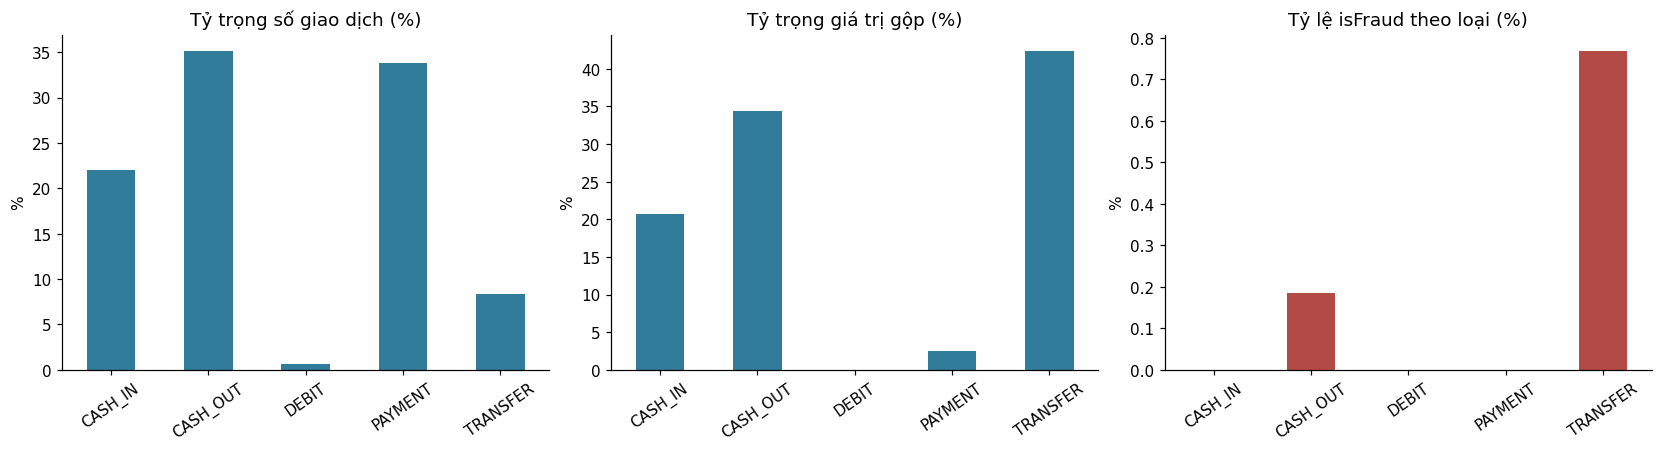

In [3]:
type_summary = df.groupby("type", observed=True).agg(
    transactions=("amount", "size"), gross_amount=("amount", "sum"),
    median_amount=("amount", "median"), fraud_transactions=("isFraud", "sum"),
)
fraud_amounts = df.loc[df.isFraud.eq(1)].groupby("type", observed=True).amount.sum()
type_summary["fraud_amount"] = fraud_amounts.reindex(type_summary.index, fill_value=0)
type_summary["transaction_share"] = type_summary.transactions / len(df)
type_summary["amount_share"] = type_summary.gross_amount / df.amount.sum()
type_summary["fraud_rate"] = type_summary.fraud_transactions / type_summary.transactions
type_summary["fraud_amount_share"] = type_summary.fraud_amount / type_summary.gross_amount
display(type_summary)
full_stats = {"rows": len(df), "frauds": int(df.isFraud.sum()),
              "fraud_rate": float(df.isFraud.mean()), "amount": float(df.amount.sum())}
display(Markdown(f"**Toàn bộ CSV:** {len(df):,} giao dịch, {full_stats['frauds']:,} giao dịch có nhãn "
                 f"({full_stats['fraud_rate']:.4%}). Accuracy của cách luôn dự đoán không gian lận "
                 f"đã đạt {1-full_stats['fraud_rate']:.4%}; vì vậy accuracy đơn lẻ ít hữu ích."))
fig, ax = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
for axis, column, title, color in zip(ax,
    ["transaction_share", "amount_share", "fraud_rate"],
    ["Tỷ trọng số giao dịch (%)", "Tỷ trọng giá trị gộp (%)", "Tỷ lệ isFraud theo loại (%)"],
    ["#327c9b", "#327c9b", "#b34a45"]):
    (type_summary[column] * 100).plot.bar(ax=axis, color=color, rot=35)
    axis.set(title=title, xlabel="", ylabel="%")
plt.show()


### Phân phối số tiền và thay đổi theo thời gian

Giá trị rất lớn cần được đặt trong bối cảnh loại giao dịch, thay vì dùng một ngưỡng chung cho tất cả.
Ngưỡng 10.000 phía sau là tham số minh họa từ đề bài, không phải ngưỡng pháp lý hoặc ngưỡng tối ưu.
Đồ thị phân phối dùng mẫu cố định để hiển thị; bảng định lượng và chuỗi thời gian dùng toàn bộ CSV.
Ở biểu đồ tỷ lệ theo giờ, màu thể hiện số giao dịch của giờ đó; tỷ lệ 100% với rất ít giao dịch không tương đương rủi ro 100% trên toàn hệ thống.


p50            p90             p99
type     isFraud                                            
CASH_IN  0       143,427.7100   343,358.1400    550,870.8625
CASH_OUT 0       146,946.5600   354,311.0710    572,665.0518
         1       435,516.9050 4,453,316.6850 10,000,000.0000
DEBIT    0         3,048.9900     9,500.1070     50,817.9838
PAYMENT  0         9,482.1900    28,810.7340     59,500.1066
TRANSFER 0       486,521.9100 1,771,407.8660 10,000,000.0000
         1       445,705.7600 4,565,651.6360 10,000,000.0000

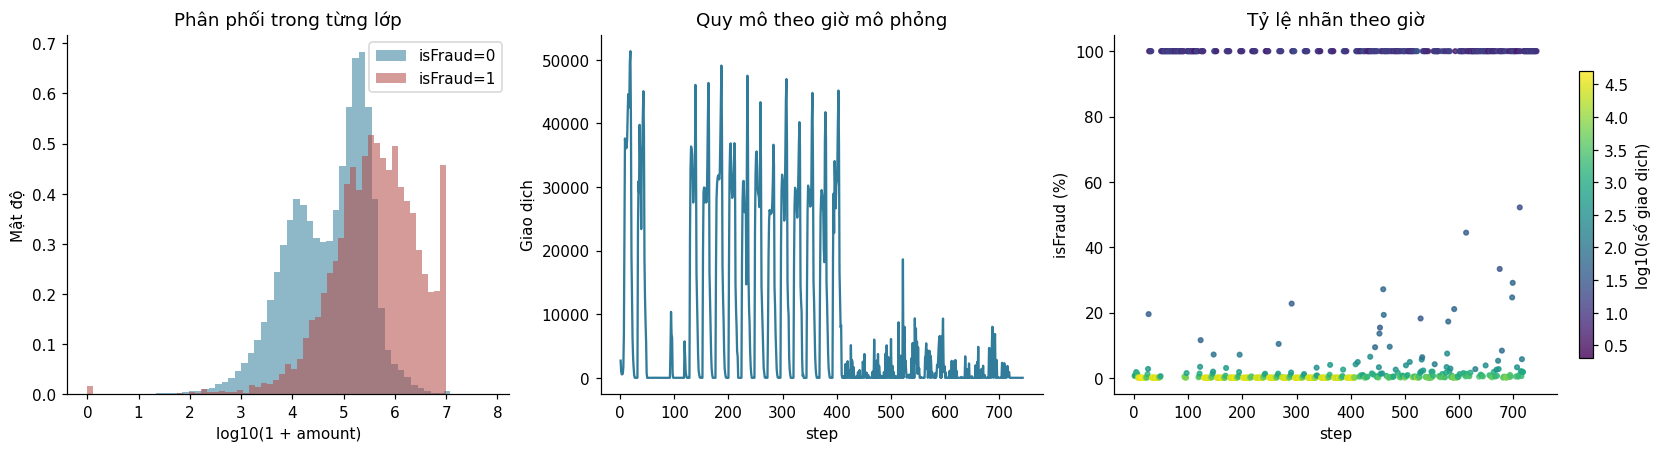

,transactions,gross_amount,frauds,fraud_rate
step,,,,
28,4,"8,647,152.2200",4,1.0000
29,4,"1,217,680.4600",4,1.0000
30,8,"975,200.9200",8,1.0000
31,12,"12,927,128.0400",12,1.0000
32,12,"9,361,820.0800",12,1.0000


In [4]:
display(df.groupby(["type", "isFraud"], observed=True).amount.quantile([.5, .9, .99])
        .unstack().rename(columns={.5: "p50", .9: "p90", .99: "p99"}))
hourly = df.groupby("step").agg(transactions=("amount", "size"),
                               gross_amount=("amount", "sum"), frauds=("isFraud", "sum"))
hourly["fraud_rate"] = hourly.frauds / hourly.transactions
fig, ax = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
for label, color in [(0, "#327c9b"), (1, "#b34a45")]:
    amounts = df.loc[df.isFraud.eq(label), "amount"]
    sample = amounts.sample(n=min(100_000, len(amounts)), random_state=SEED)
    ax[0].hist(np.log10(1 + sample), bins=60, density=True, alpha=.55,
               label=f"isFraud={label}", color=color)
ax[0].set(title="Phân phối trong từng lớp", xlabel="log10(1 + amount)", ylabel="Mật độ")
ax[0].legend()
ax[1].plot(hourly.index, hourly.transactions, color="#327c9b")
ax[1].set(title="Quy mô theo giờ mô phỏng", xlabel="step", ylabel="Giao dịch")
rate_points = ax[2].scatter(hourly.index, 100 * hourly.fraud_rate,
    c=np.log10(hourly.transactions), s=9, cmap="viridis", alpha=.8)
ax[2].set(title="Tỷ lệ nhãn theo giờ", xlabel="step", ylabel="isFraud (%)")
fig.colorbar(rate_points, ax=ax[2], label="log10(số giao dịch)", shrink=.8)
plt.show()
display(hourly.nlargest(5, "fraud_rate"))


### Số dư: dữ liệu quan sát hay dấu vết của mô phỏng?

Với giao dịch chi ra, kiểm tra `oldbalanceOrg - amount - newbalanceOrig`; với CASH_IN, kiểm tra dấu cộng.
Sai lệch không tự chứng minh gian lận: có thể liên quan ngữ nghĩa sự kiện, số dư thiếu hoặc quy tắc mô phỏng.
Ngay cả một đặc trưng phân tách nhãn rất tốt cũng có thể là artifact của simulator.
`newbalance*` chỉ có sau giao dịch, nên không được dùng cho quyết định chặn giao dịch trước khi xử lý.


In [5]:
sign = np.where(df.type.eq("CASH_IN"), 1.0, -1.0)
origin_residual = df.oldbalanceOrg + sign * df.amount - df.newbalanceOrig
balance_audit = df[["type", "isFraud"]].assign(
    origin_balance_mismatch=np.abs(origin_residual) > .01,
    zero_origin_before=df.oldbalanceOrg.eq(0),
    zero_destination_both=df.oldbalanceDest.eq(0) & df.newbalanceDest.eq(0),
).groupby(["type", "isFraud"], observed=True).mean()
display(balance_audit)
del sign, origin_residual


origin_balance_mismatch  zero_origin_before  \
type     isFraud                                                
CASH_IN  0                         0.0722              0.0096   
CASH_OUT 0                         0.8916              0.4593   
         1                         0.0058              0.0090   
DEBIT    0                         0.3008              0.1486   
PAYMENT  0                         0.5419              0.3599   
TRANSFER 0                         0.9621              0.5347   
         1                         0.0051              0.0010   

                  zero_destination_both  
type     isFraud                         
CASH_IN  0                       0.1143  
CASH_OUT 0                       0.0007  
         1                       0.0019  
DEBIT    0                       0.0000  
PAYMENT  0                       1.0000  
TRANSFER 0                       0.0002  
         1                       0.9929

## 4. Dữ liệu có hỗ trợ theo dõi nhiều chặng không?

Một node phải có cả incoming và outgoing edges mới có thể nằm trong vòng chuyển tiền có hướng.
Tỷ lệ ID lặp và giao giữa tập gửi/nhận giúp kiểm tra khả năng này trước khi chạy thuật toán.
Giao giữa hai tập chỉ là điều kiện cần; nó chưa chứng minh có đường đi theo đúng thứ tự thời gian.
ID giống nhau cũng cần được đối chiếu với cơ chế sinh ID trước khi suy ra cùng chủ tài khoản ngoài đời.


In [6]:
sources = pd.Index(df.nameOrig.unique())
destinations = pd.Index(df.nameDest.unique())
overlap = sources.intersection(destinations)
continuity = pd.Series({"unique_origins": len(sources), "unique_destinations": len(destinations),
    "unique_accounts": len(sources.union(destinations)), "both_roles": len(overlap),
    "both_roles_share": len(overlap) / len(sources.union(destinations)),
    "repeated_origin_row_share": float(df.nameOrig.duplicated().mean())})
display(continuity.to_frame("full CSV"))

window = df.loc[df.step.between(GRAPH_START, GRAPH_END)].copy()
graph_rows = window.loc[window.type.isin(GRAPH_TYPES)].copy()
assert len(graph_rows), "Cửa sổ/type hiện tại không có cạnh."
scope = pd.DataFrame({
    "transactions": [len(df), len(window), len(graph_rows)],
    "gross_amount": [df.amount.sum(), window.amount.sum(), graph_rows.amount.sum()],
    "fraud_rate": [df.isFraud.mean(), window.isFraud.mean(), graph_rows.isFraud.mean()],
}, index=["Full CSV", f"All types, step {GRAPH_START}-{GRAPH_END}", "Graph: TRANSFER window"])
scope["share_of_all_rows"] = scope.transactions / len(df)
display(scope)
graph_overlap = pd.Index(graph_rows.nameOrig.unique()).intersection(graph_rows.nameDest.unique())
print("ID có cả hai vai trò trong đồ thị:", len(graph_overlap))
print("Đây là thống kê của cửa sổ, không phải ước lượng đại diện toàn bộ mạng.")


,full CSV
unique_origins,"6,353,307.0000"
unique_destinations,"2,722,362.0000"
unique_accounts,"9,073,900.0000"
both_roles,"1,769.0000"
both_roles_share,0.0002
repeated_origin_row_share,0.0015


,transactions,gross_amount,fraud_rate,share_of_all_rows
Full CSV,6362620,"1,144,392,944,759.7700",0.0013,1.0000
"All types, step 1-24",574255,"92,131,865,625.6500",0.0005,0.0903
Graph: TRANSFER window,46686,"31,178,878,559.6000",0.0028,0.0073


ID có cả hai vai trò trong đồ thị: 0
Đây là thống kê của cửa sổ, không phải ước lượng đại diện toàn bộ mạng.


### Giả thuyết sát PaySim hơn: nhận TRANSFER rồi CASH_OUT

Ghép đúng ID nhận TRANSFER với ID thực hiện CASH_OUT; chỉ giữ chặng rút ở giờ sau và trong 24 giờ.
Không ghép theo số tiền gần nhau vì nhiều khách hàng có thể giao dịch cùng số tiền.
Không tìm thấy cặp ghép được cũng là kết quả hữu ích về giới hạn dữ liệu.
Một cặp ghép được chỉ là ứng viên liên quan; chưa chứng minh tiền rút chính là tiền vừa nhận.


In [7]:
incoming = window.loc[window.type.eq("TRANSFER"), ["nameOrig", "nameDest", "step", "amount"]].rename(
    columns={"nameOrig": "sender", "nameDest": "account", "step": "in_step", "amount": "in_amount"})
cashout = window.loc[window.type.eq("CASH_OUT"), ["nameOrig", "nameDest", "step", "amount"]].rename(
    columns={"nameOrig": "account", "nameDest": "cashout_counterparty", "step": "out_step", "amount": "out_amount"})
routes = incoming.merge(cashout, on="account", how="inner")
routes = routes.loc[(routes.out_step > routes.in_step) & (routes.out_step - routes.in_step <= 24)].copy()
routes["out_to_in_amount"] = routes.out_amount / routes.in_amount.replace(0, np.nan)
print("Số cặp TRANSFER -> CASH_OUT đúng ID, khác giờ trong cửa sổ:", len(routes))
display(routes.head(10))
del incoming, cashout, routes, df, window, sources, destinations, overlap, amounts, sample
gc.collect()


Số cặp TRANSFER -> CASH_OUT đúng ID, khác giờ trong cửa sổ: 0


,sender,account,in_step,in_amount,cashout_counterparty,out_step,out_amount,out_to_in_amount


36

## 5. Task 1: dựng GraphFrame với ngữ nghĩa rõ ràng

Phần này là nội dung `graph_analysis.py` được giữ ngay trong notebook để chạy độc lập.
`vertices` gồm `id`, `account_type`, `balance`; `edges` gồm `src`, `dst`, `amount`, `timestamp` và thuộc tính giao dịch.
`timestamp` giữ nguyên số giờ mô phỏng; không gán ngày lịch giả.

`balance` là số dư sau giao dịch được quan sát ở step mới nhất **trong cửa sổ** cho từng ID.
Nếu cùng giờ mới nhất có nhiều số dư khác nhau, đặt `balance = null` và bật `balance_ambiguous`, vì không có thứ tự nội giờ.
Số dư merchant để null; không cộng các ảnh chụp số dư lại.
Đây là thuộc tính mô tả cuối cửa sổ, không phải feature dùng trước giao dịch.

Giữ nhiều cạnh cùng cặp ID vì đó có thể là các giao dịch khác nhau.
`event_id` chỉ là khóa cục bộ trong lần nạp này, không phải transaction_id do nhà cung cấp xác nhận.


In [8]:
import shutil
local_java = RUNTIME / "jdk"
if (local_java / "bin/java").is_file():
    os.environ["JAVA_HOME"] = str(local_java)
if not shutil.which("java") and not os.environ.get("JAVA_HOME"):
    raise RuntimeError("Cần cài JDK 17/21 đầy đủ và thiết lập JAVA_HOME trước khi chạy Spark.")
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
from pyspark.sql import SparkSession, functions as F, types as T, Window
from graphframes import GraphFrame

spark = (SparkSession.builder.master("local[2]").appName("PaySim-business-EDA")
    .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.12.2")
    .config("spark.jars.ivy", str(RUNTIME / "ivy"))
    .config("spark.local.dir", str(RUNTIME / "spark-tmp"))
    .config("spark.driver.memory", "3g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
spark.sparkContext.setCheckpointDir(str(RUNTIME / "checkpoints"))
print("Spark:", spark.version)

schema = T.StructType([
    T.StructField("step", T.IntegerType()), T.StructField("type", T.StringType()),
    T.StructField("amount", T.DoubleType()), T.StructField("nameOrig", T.StringType()),
    T.StructField("oldbalanceOrg", T.DoubleType()), T.StructField("newbalanceOrig", T.DoubleType()),
    T.StructField("nameDest", T.StringType()), T.StructField("oldbalanceDest", T.DoubleType()),
    T.StructField("newbalanceDest", T.DoubleType()), T.StructField("isFraud", T.IntegerType()),
    T.StructField("isFlaggedFraud", T.IntegerType()),
])
transactions = (spark.read.option("header", True).option("mode", "FAILFAST").schema(schema).csv(str(DATA))
    .filter(F.col("step").between(GRAPH_START, GRAPH_END))
    .filter(F.col("type").isin(*GRAPH_TYPES)).cache())

def build_graph(transactions):
    edges = transactions.select(
        F.col("nameOrig").alias("src"), F.col("nameDest").alias("dst"),
        "amount", F.col("step").alias("timestamp"), "type", "isFraud", "isFlaggedFraud",
    ).withColumn("event_id", F.monotonically_increasing_id()).cache()
    observations = transactions.select(
        F.col("nameOrig").alias("id"), "step", F.col("newbalanceOrig").alias("observed_balance")
    ).unionByName(transactions.select(
        F.col("nameDest").alias("id"), "step", F.col("newbalanceDest").alias("observed_balance")))
    latest = observations.withColumn("latest_step", F.max("step").over(Window.partitionBy("id")))
    latest = latest.filter(F.col("step") == F.col("latest_step")).groupBy("id").agg(
        F.max("step").alias("balance_step"), F.countDistinct("observed_balance").alias("balance_variants"),
        F.max("observed_balance").alias("observed_balance"))
    vertices = (latest.withColumn("account_type",
        F.when(F.col("id").startswith("M"), "merchant_like")
         .when(F.col("id").startswith("C"), "customer_like").otherwise("unknown"))
        .withColumn("balance_ambiguous", F.col("balance_variants") > 1)
        .withColumn("balance", F.when((F.col("account_type") != "merchant_like") &
                                     (F.col("balance_variants") == 1), F.col("observed_balance")))
        .select("id", "account_type", "balance", "balance_step", "balance_ambiguous").cache())
    return GraphFrame(vertices, edges)

graph = build_graph(transactions)
vertices, edges = graph.vertices, graph.edges
n_vertices, n_edges = vertices.count(), edges.count()
assert n_edges == len(graph_rows)
assert n_vertices == pd.concat([graph_rows.nameOrig, graph_rows.nameDest]).nunique()
assert vertices.select("id").distinct().count() == n_vertices
assert edges.join(vertices, edges.src == vertices.id, "left_anti").limit(1).count() == 0
assert edges.join(vertices, edges.dst == vertices.id, "left_anti").limit(1).count() == 0
display(vertices.limit(5).toPandas())
display(edges.limit(5).toPandas())
print(f"Graph: {n_vertices:,} vertices; {n_edges:,} transaction edges.")


:: loading settings :: url = jar:file:/data/graphX/notebook-env/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /data/graphX/notebook-runtime/ivy/cache
The jars for the packages stored in: /data/graphX/notebook-runtime/ivy/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-5bc911b6-5885-467e-8c0b-80dde97c32fe;1.0
	confs: [default]


	found io.graphframes#graphframes-spark4_2.13;0.12.2 in central
	found io.graphframes#graphframes-graphx-spark4_2.13;0.12.2 in central
	found org.apache.datasketches#datasketches-java;6.2.0 in central
	found org.apache.datasketches#datasketches-memory;3.0.2 in central
:: resolution report :: resolve 203ms :: artifacts dl 4ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark4_2.13;0.12.2 from central in [default]
	io.graphframes#graphframes-spark4_2.13;0.12.2 from central in [default]
	org.apache.datasketches#datasketches-java;6.2.0 from central in [default]
	org.apache.datasketches#datasketches-memory;3.0.2 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   4   |   0   |   0   |   0   ||   4   |  

26/10/05 22:39:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/05 22:39:46 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


Spark: 4.0.1


,id,account_type,balance,balance_step,balance_ambiguous
0,C1000109302,customer_like,0.0000,10,False
1,C1000157415,customer_like,"929,396.1400",20,False
2,C1000471237,customer_like,0.0000,18,False
3,C1000630508,customer_like,"1,025,757.4900",13,False
4,C1000715148,customer_like,0.0000,11,False


,src,dst,amount,timestamp,type,isFraud,isFlaggedFraud,event_id
0,C1305486145,C553264065,181.0000,1,TRANSFER,1,0,0
1,C1670993182,C1100439041,"215,310.3000",1,TRANSFER,0,0,1
2,C1984094095,C932583850,"311,685.8900",1,TRANSFER,0,0,2
3,C1976401987,C1937962514,"62,610.8000",1,TRANSFER,0,0,3
4,C283039401,C1330106945,"42,712.3900",1,TRANSFER,0,0,4


Graph: 68,981 vertices; 46,686 transaction edges.


## 6. Task 2: degree, giá trị luân chuyển và PageRank

In-degree/out-degree trên multigraph đếm **giao dịch**, không đếm đối tác khác nhau.
Vì vậy cần đặt degree cạnh `unique_senders`, `unique_receivers`, `in_amount`, `out_amount`.
Node nhiều người gửi có thể là tài khoản gom tiền, nhưng cũng có thể là đầu mối thanh toán hợp lệ.
Node chỉ nhận tiền dễ đứng cao trong PageRank; điều đó không tự biến node thành một trung gian nhiều chặng.


,id,inDegree,outDegree,degree,in_amount,unique_senders,out_amount,unique_receivers
25707,C97730845,20,0,20,"28,009,878.8600",20,0.0000,0
37038,C1590550415,20,0,20,"26,350,395.9200",20,0.0000,0
41415,C665576141,24,0,24,"24,904,533.0300",24,0.0000,0
56774,C248609774,24,0,24,"24,711,862.8000",24,0.0000,0
3983,C1883840933,19,0,19,"23,864,765.2100",19,0.0000,0
30563,C2083562754,18,0,18,"21,989,217.7100",18,0.0000,0
8082,C863811613,18,0,18,"21,868,866.9900",18,0.0000,0
18837,C1360767589,22,0,22,"21,756,362.9200",22,0.0000,0
14880,C451111351,20,0,20,"19,783,480.3400",20,0.0000,0
67691,C716083600,18,0,18,"19,569,066.7800",18,0.0000,0


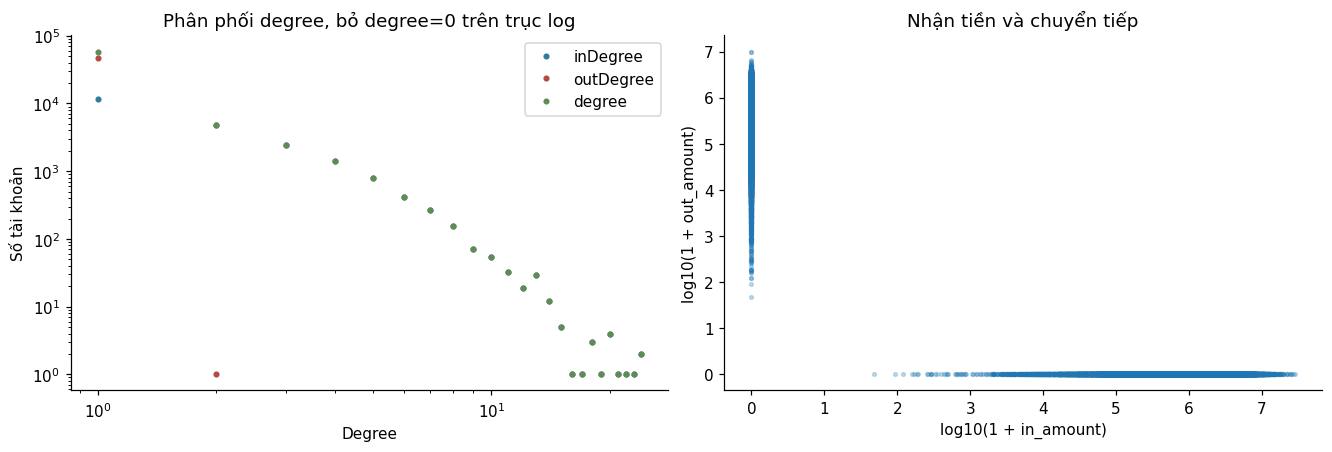

In [9]:
degree = (vertices.select("id").join(graph.inDegrees, "id", "left")
          .join(graph.outDegrees, "id", "left").fillna(0, ["inDegree", "outDegree"])
          .withColumn("degree", F.col("inDegree") + F.col("outDegree")))
flows_in = edges.groupBy("dst").agg(F.sum("amount").alias("in_amount"),
    F.countDistinct("src").alias("unique_senders")).withColumnRenamed("dst", "id")
flows_out = edges.groupBy("src").agg(F.sum("amount").alias("out_amount"),
    F.countDistinct("dst").alias("unique_receivers")).withColumnRenamed("src", "id")
metrics = (degree.join(flows_in, "id", "left").join(flows_out, "id", "left")
           .fillna(0, ["in_amount", "out_amount", "unique_senders", "unique_receivers"]).cache())
totals = metrics.agg(F.sum("inDegree"), F.sum("outDegree"), F.sum("degree")).first()
assert tuple(totals) == (n_edges, n_edges, 2 * n_edges)
metric_pd = metrics.toPandas()
display(metric_pd.nlargest(10, "in_amount"))
fig, ax = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for field, color in [("inDegree", "#327c9b"), ("outDegree", "#b34a45"), ("degree", "#628b54")]:
    counts = metric_pd[field].value_counts().sort_index()
    counts = counts[counts.index > 0]
    ax[0].loglog(counts.index, counts.values, ".", label=field, color=color)
ax[0].set(title="Phân phối degree, bỏ degree=0 trên trục log", xlabel="Degree", ylabel="Số tài khoản")
ax[0].legend()
ax[1].scatter(np.log10(1+metric_pd.in_amount), np.log10(1+metric_pd.out_amount), s=6, alpha=.25)
ax[1].set(title="Nhận tiền và chuyển tiếp", xlabel="log10(1 + in_amount)", ylabel="log10(1 + out_amount)")
plt.show()


### Top 10 hub theo PageRank

Chạy đúng `resetProbability=0.15, maxIter=10` trên cạnh giao dịch có hướng.
GraphFrames PageRank không dùng `amount` làm trọng số; cạnh lặp ảnh hưởng theo số giao dịch.
Mười vòng lặp là ngân sách tính toán đã chọn, không phải bằng chứng thuật toán đã hội tụ.
Bảng top 10 giúp định vị hub cấu trúc trong cửa sổ, không phải top 10 tài khoản gian lận.


,id,pagerank,account_type,inDegree,outDegree,degree,in_amount,unique_senders,out_amount,unique_receivers
0,C248609774,13.5850,customer_like,24,0,24,"24,711,862.8000",24,0.0000,0
1,C665576141,13.5850,customer_like,24,0,24,"24,904,533.0300",24,0.0000,0
2,C1286084959,13.0454,customer_like,23,0,23,"16,822,067.5400",23,0.0000,0
3,C1360767589,12.5058,customer_like,22,0,22,"21,756,362.9200",22,0.0000,0
4,C306206744,11.9663,customer_like,21,0,21,"13,017,078.4400",21,0.0000,0
5,C1590550415,11.4267,customer_like,20,0,20,"26,350,395.9200",20,0.0000,0
6,C451111351,11.4267,customer_like,20,0,20,"19,783,480.3400",20,0.0000,0
7,C97730845,11.4267,customer_like,20,0,20,"28,009,878.8600",20,0.0000,0
8,C985934102,11.4267,customer_like,20,0,20,"13,548,109.8400",20,0.0000,0
9,C1883840933,10.8871,customer_like,19,0,19,"23,864,765.2100",19,0.0000,0


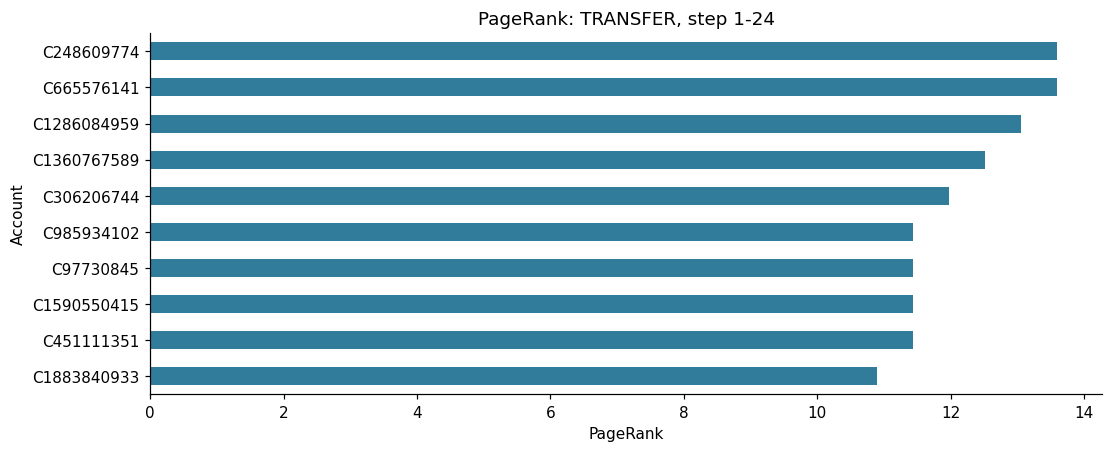

In [10]:
ranked_graph = graph.pageRank(resetProbability=0.15, maxIter=10)
top_hubs = (ranked_graph.vertices.select("id", "pagerank", "account_type")
    .join(metrics, "id").orderBy(F.desc("pagerank"), "id").limit(10).toPandas())
display(top_hubs)
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
top_hubs.sort_values("pagerank").plot.barh(x="id", y="pagerank", ax=ax, color="#327c9b", legend=False)
ax.set(title=f"PageRank: TRANSFER, step {GRAPH_START}-{GRAPH_END}", xlabel="PageRank", ylabel="Account")
plt.show()
ranked_graph.vertices.unpersist()
_ = ranked_graph.edges.unpersist()


## 7. Task 3: vòng chuyển tiền A → B → C → A

Một vòng cấu trúc chưa đủ: ba tài khoản phải khác nhau, từng chặng vượt ngưỡng, và thời gian phải hợp lý.
Chỉ giữ một phép quay của mỗi chu trình bằng `a.id < b.id` và `a.id < c.id`; hướng ngược lại vẫn là chu trình khác.
Không áp điều kiện ID nhỏ nhất cho việc xác định chặng sớm nhất, vì tên tài khoản không liên quan thời gian.

Ta báo cáo riêng vòng cấu trúc, vòng theo thứ tự giờ nghiêm ngặt và vòng có chặng cùng giờ chưa xác định được thứ tự.
Các event khác nhau trên cùng bộ ba ID được giữ riêng, còn số bộ ba tài khoản cũng được báo cáo riêng.


In [11]:
def find_cycles(g, threshold=10_000.0, max_hours=24):
    # Lọc trước join để hạn chế số lượng tổ hợp motif.
    high = GraphFrame(g.vertices, g.edges.filter(F.col("amount") > threshold))
    motifs = high.find("(a)-[e1]->(b); (b)-[e2]->(c); (c)-[e3]->(a)").filter(
        (F.col("a.id") < F.col("b.id")) & (F.col("a.id") < F.col("c.id")) &
        (F.col("b.id") != F.col("c.id")))
    t1, t2, t3 = [F.col(f"e{i}.timestamp") for i in (1, 2, 3)]
    ordered = ((t1 < t2) & (t2 < t3)) | ((t2 < t3) & (t3 < t1)) | ((t3 < t1) & (t1 < t2))
    tied = (t1 == t2) | (t2 == t3) | (t3 == t1)
    return (motifs.withColumn("span_hours", F.greatest(t1, t2, t3) - F.least(t1, t2, t3))
        .withColumn("strict_temporal_cycle", ordered & (F.col("span_hours") <= max_hours))
        .withColumn("same_hour_uncertain", tied & (F.col("span_hours") <= max_hours)))

cycles = find_cycles(graph, AMOUNT_THRESHOLD, MAX_CYCLE_HOURS).cache()
cycle_counts = {"structural_event_cycles": cycles.count(),
    "directed_account_triples": cycles.select("a.id", "b.id", "c.id").distinct().count(),
    "strict_temporal_cycles": cycles.filter("strict_temporal_cycle").count(),
    "same_hour_uncertain": cycles.filter("same_hour_uncertain").count()}
display(pd.Series(cycle_counts).to_frame("count"))
display(cycles.select(F.col("a.id").alias("a"), F.col("b.id").alias("b"), F.col("c.id").alias("c"),
    "span_hours", "strict_temporal_cycle", "same_hour_uncertain").limit(10).toPandas())
if cycle_counts["structural_event_cycles"] == 0:
    print("Không thấy chu trình 3 node vượt ngưỡng trong cửa sổ đã chọn.")
    print("Kết quả này không loại trừ chu trình dài hơn, số tiền nhỏ hơn hoặc đường đi ngoài cửa sổ.")
_ = cycles.unpersist()


,count
structural_event_cycles,0
directed_account_triples,0
strict_temporal_cycles,0
same_hour_uncertain,0


,a,b,c,span_hours,strict_temporal_cycle,same_hour_uncertain


Không thấy chu trình 3 node vượt ngưỡng trong cửa sổ đã chọn.
Kết quả này không loại trừ chu trình dài hơn, số tiền nhỏ hơn hoặc đường đi ngoài cửa sổ.


### Kiểm chứng thuật toán bằng dữ liệu kiểm thử tách biệt

Đồ thị nhỏ dưới đây là **dữ liệu tự tạo để kiểm thử**, không bổ sung vào PaySim và không được tính vào phát hiện thực tế.
Vòng `A→B→C→A` cố ý có giao dịch sớm nhất tại B, nhằm kiểm tra loại phép quay không làm mất trình tự thời gian hợp lệ.
Thêm một vòng cùng giờ và một vòng đi ngược thứ tự thời gian để kiểm tra hai trường hợp dễ diễn giải sai.


In [12]:
toy_v = spark.createDataFrame([(x,) for x in "ABCDEFGHI"], ["id"])
toy_e = spark.createDataFrame([
    ("A", "B", 12000., 3), ("B", "C", 11900., 1), ("C", "A", 11800., 2),
    ("D", "E", 12000., 1), ("E", "F", 11900., 1), ("F", "D", 11800., 1),
    ("G", "H", 12000., 1), ("H", "I", 11900., 3), ("I", "G", 11800., 2),
], "src string, dst string, amount double, timestamp int")
toy_cycles = find_cycles(GraphFrame(toy_v, toy_e)).cache()
assert toy_cycles.count() == 3
assert toy_cycles.filter("strict_temporal_cycle").count() == 1
assert toy_cycles.filter("same_hour_uncertain").count() == 1
assert find_cycles(GraphFrame(toy_v, toy_e), threshold=12000).count() == 0
toy_cycles.unpersist()
print("PASS: motif, threshold strict >, permutation, time ordering và same-hour ambiguity.")


PASS: motif, threshold strict >, permutation, time ordering và same-hour ambiguity.


## 8. Task 4: cộng đồng và thành phần liên thông

**Connected component** trả lời ai có thể liên hệ với ai khi bỏ chiều cạnh; nó không đảm bảo mọi cặp chuyển tiền được cho nhau.
**LPA** gán nhóm dựa trên láng giềng; cùng nhãn không đồng nghĩa cô lập, liên thông chặt hoặc có mục đích phạm tội.
Ta dùng đồ thị quan hệ đơn vô hướng cho LPA: mỗi cặp đối tác chỉ bỏ một phiếu, tránh nhầm nhiều giao dịch với nhiều đối tác.
LPA có thể dao động hoặc cho nghiệm tầm thường; không coi mã nhãn là định danh cộng đồng bền vững.

Đo thêm density, tỷ lệ cạnh ra ngoài nhóm và giá trị nội bộ trên đồ thị TRANSFER gốc.
Các chỉ số này phản ánh riêng cửa sổ và loại giao dịch đã chọn.


In [13]:
pairs = edges.filter(F.col("src") != F.col("dst")).select(
    F.least("src", "dst").alias("src"), F.greatest("src", "dst").alias("dst")).distinct().cache()
relationship_graph = GraphFrame(vertices, pairs)
components = relationship_graph.connectedComponents(algorithm="graphx").cache()
labels = relationship_graph.labelPropagation(maxIter=LPA_ITERATIONS).cache()
component_sizes = components.groupBy("component").count().withColumnRenamed("count", "accounts")
lpa_sizes = labels.groupBy("label").count().withColumnRenamed("count", "accounts")
print("Weakly connected components:", component_sizes.count())
print("LPA labels:", lpa_sizes.count())
display(component_sizes.orderBy(F.desc("accounts")).limit(10).toPandas())
display(lpa_sizes.orderBy(F.desc("accounts")).limit(10).toPandas())

label_pd = labels.select("id", "label").toPandas().set_index("id").label
edge_pd = edges.select("src", "dst", "amount", "timestamp", "isFraud").toPandas()
pair_pd = pairs.toPandas()
pair_pd["src_label"] = pair_pd.src.map(label_pd)
pair_pd["dst_label"] = pair_pd.dst.map(label_pd)
internal_pairs = pair_pd.loc[pair_pd.src_label.eq(pair_pd.dst_label)]
external_pairs = pair_pd.loc[pair_pd.src_label.ne(pair_pd.dst_label)]
communities = label_pd.value_counts().rename("accounts").to_frame()
communities.index.name = "label"
communities["internal_pairs"] = internal_pairs.groupby("src_label").size().reindex(communities.index, fill_value=0)
boundary = pd.concat([external_pairs.src_label, external_pairs.dst_label]).value_counts()
communities["boundary_pairs"] = boundary.reindex(communities.index, fill_value=0)
possible_pairs = communities.accounts * (communities.accounts - 1) / 2
communities["density"] = communities.internal_pairs / possible_pairs.replace(0, np.nan)
incident_pairs = communities.internal_pairs + communities.boundary_pairs
communities["boundary_share"] = communities.boundary_pairs / incident_pairs.replace(0, np.nan)
edge_pd["src_label"] = edge_pd.src.map(label_pd)
edge_pd["dst_label"] = edge_pd.dst.map(label_pd)
internal_events = edge_pd.loc[edge_pd.src_label.eq(edge_pd.dst_label)]
communities["internal_amount"] = internal_events.groupby("src_label").amount.sum().reindex(communities.index, fill_value=0)
communities["internal_transactions"] = internal_events.groupby("src_label").size().reindex(communities.index, fill_value=0)
assert communities.density.dropna().between(0, 1).all()
assert communities.boundary_share.dropna().between(0, 1).all()
display(communities.sort_values("accounts", ascending=False).head(10))


Weakly connected components: 22295
LPA labels: 44592


,component,accounts
0,1756,25
1,2343,25
2,2279,24
3,894,23
4,1152,22
5,7876,21
6,2245,21
7,3848,21
8,2619,21
9,1590,20


,label,accounts
0,34359745366,24
1,51539612771,24
2,42949674155,23
3,17179870719,22
4,25769809224,21
5,8621,20
6,34359740965,20
7,17179877636,20
8,8589940797,20
9,3986,19


,accounts,internal_pairs,boundary_pairs,density,boundary_share,internal_amount,internal_transactions
label,,,,,,,
34359745366,24,0,24,0.0000,1.0000,0.0000,0
51539612771,24,0,24,0.0000,1.0000,0.0000,0
42949674155,23,0,23,0.0000,1.0000,0.0000,0
17179870719,22,0,22,0.0000,1.0000,0.0000,0
25769809224,21,0,21,0.0000,1.0000,0.0000,0
34359740965,20,0,20,0.0000,1.0000,0.0000,0
8589940797,20,0,20,0.0000,1.0000,0.0000,0
8621,20,0,20,0.0000,1.0000,0.0000,0
17179877636,20,0,20,0.0000,1.0000,0.0000,0


### Cụm nào thực sự đáng xem xét?

Không dùng một điểm rủi ro tổng hợp với trọng số tùy ý.
Minh họa một bộ lọc có thể giải thích: 3-50 node, liên thông nội bộ, density ≥ 0,3 và boundary share ≤ 0,1; đây là giả thuyết cần hiệu chỉnh với ngân sách điều tra.
Cụm hình sao nhỏ vẫn có thể vượt ngưỡng density, nên cần kiểm tra số vòng độc lập và tỷ lệ node có cả nhận lẫn gửi.
Số vòng độc lập tính trên đồ thị vô hướng không tương đương chu trình tiền có hướng.


,accounts,internal_pairs,boundary_pairs,density,boundary_share,internal_amount,internal_transactions,independent_undirected_cycles,internal_connected_components,both_roles_share
label,,,,,,,,,,


Cụm vượt bộ lọc cấu trúc: 0
Trong đó có vòng vô hướng: 0
Nhãn LPA chứa nhiều thành phần rời nhau: 10602


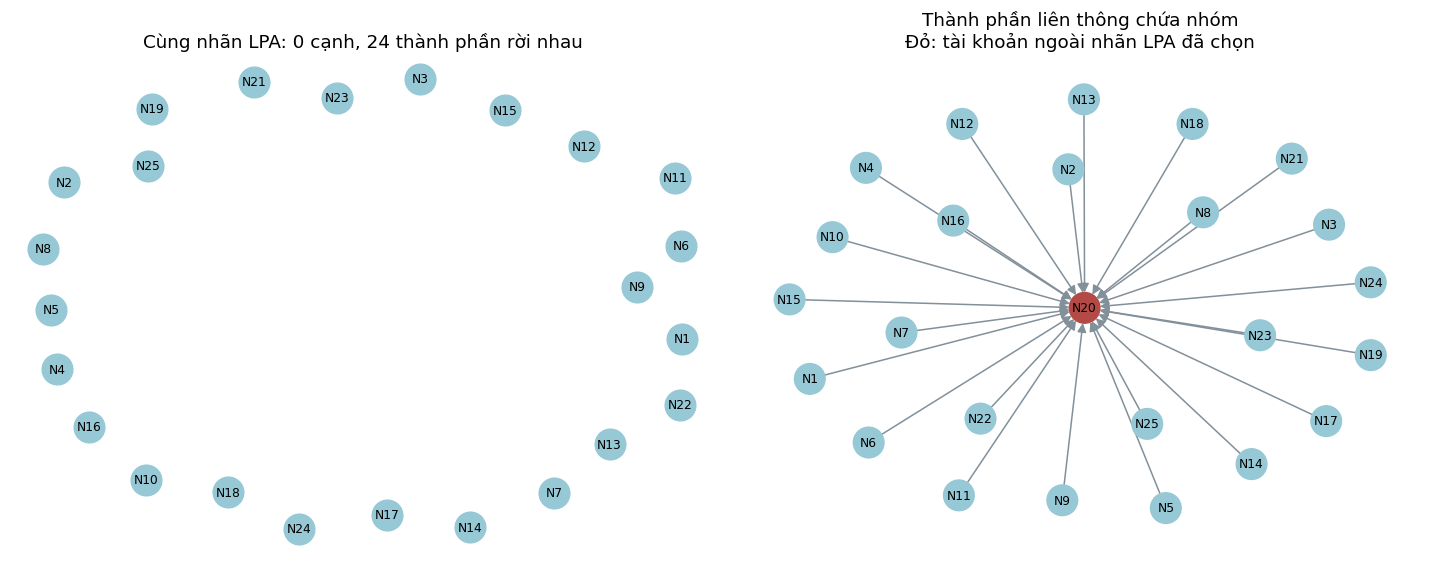

,display_id,account
0,N3,C1384845686
1,N6,C1565193331
2,N10,C1996817120
3,N8,C1758060579
4,N12,C2036443363
5,N19,C555943503
6,N22,C761252104
7,N16,C355885103
8,N25,C926859124
9,N17,C355985592


In [14]:
import networkx as nx
relation_nx = nx.Graph()
relation_nx.add_nodes_from(label_pd.index)
relation_nx.add_edges_from(pair_pd[["src", "dst"]].itertuples(index=False, name=None))
assert nx.number_connected_components(relation_nx) == component_sizes.count()
cycle_ranks, internal_components = {}, {}
for label, members in label_pd.groupby(label_pd):
    sub = relation_nx.subgraph(members.index)
    internal_components[label] = nx.number_connected_components(sub)
    cycle_ranks[label] = sub.number_of_edges() - sub.number_of_nodes() + internal_components[label]
communities["independent_undirected_cycles"] = pd.Series(cycle_ranks)
communities["internal_connected_components"] = pd.Series(internal_components)
both_roles = metric_pd.set_index("id").eval("inDegree > 0 and outDegree > 0")
communities["both_roles_share"] = both_roles.groupby(label_pd).mean().reindex(communities.index)
candidates = communities.loc[communities.accounts.between(3, 50) &
                             communities.internal_connected_components.eq(1) &
                             communities.density.ge(.3) & communities.boundary_share.le(.1)].copy()
display(candidates.sort_values("internal_amount", ascending=False).head(10))
print("Cụm vượt bộ lọc cấu trúc:", len(candidates))
print("Trong đó có vòng vô hướng:", int(candidates.independent_undirected_cycles.gt(0).sum()))
print("Nhãn LPA chứa nhiều thành phần rời nhau:", int(communities.internal_connected_components.gt(1).sum()))

if len(communities):
    # Ưu tiên cụm nhỏ để hình đọc được; không lọc theo nhãn gian lận.
    visible = communities.loc[communities.accounts.between(3, 35)]
    if len(visible):
        chosen = visible.internal_amount.idxmax()
        ids = label_pd.index[label_pd.eq(chosen)]
        sub = relation_nx.subgraph(ids)
        context_ids = set().union(*(nx.node_connected_component(relation_nx, node) for node in ids))
        names = {node: f"N{i+1}" for i, node in enumerate(sorted(context_ids))}
        fig, ax = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
        positions = nx.spring_layout(sub, seed=SEED)
        nx.draw_networkx(sub, pos=positions, labels={n: names[n] for n in sub}, ax=ax[0], node_color="#96c8d6",
                         edge_color="#82909a", node_size=400, font_size=8)
        ax[0].set_title(f"Cùng nhãn LPA: {sub.number_of_edges()} cạnh, "
                        f"{nx.number_connected_components(sub)} thành phần rời nhau")
        if len(context_ids) <= 60:
            context = nx.DiGraph()
            context.add_nodes_from(context_ids)
            context_edges = edge_pd.loc[edge_pd.src.isin(context_ids) & edge_pd.dst.isin(context_ids)]
            context.add_edges_from(context_edges[["src", "dst"]].itertuples(index=False, name=None))
            colors = ["#96c8d6" if n in ids else "#b34a45" for n in context]
            nx.draw_networkx(context, pos=nx.spring_layout(context.to_undirected(), seed=SEED),
                labels=names, node_color=colors, node_size=400, font_size=8,
                edge_color="#82909a", arrowsize=12, ax=ax[1])
            ax[1].set_title("Thành phần liên thông chứa nhóm\nĐỏ: tài khoản ngoài nhãn LPA đã chọn")
        else:
            ax[1].text(.5, .5, f"Thành phần chứa {len(context_ids):,} node.\nKhông vẽ toàn bộ vì vượt 60 node.",
                       ha="center", va="center", transform=ax[1].transAxes)
        for axis in ax:
            axis.axis("off")
        plt.show()
        display(pd.DataFrame({"display_id": [names[n] for n in sub], "account": list(sub)}))
    else:
        print("Không có cộng đồng 3-35 node để hiển thị; không cắt node để tạo hình gây hiểu nhầm.")


### Kiểm tra độ nhạy LPA và đối chiếu nhãn sau phân tích

Chạy thêm LPA với 10 vòng; so tỷ lệ node thuộc cùng nhóm bằng cách ghép chéo nhãn, không so trực tiếp số ID nhãn.
Một lần chạy khác không chứng minh tính ổn định; cần kiểm tra thêm cửa sổ và cách dựng đồ thị trước khi vận hành.
Sau khi hoàn tất lựa chọn theo cấu trúc mới nối `isFraud` để mô tả tỷ lệ nhãn trên **giao dịch nội bộ**.
Không dùng nhãn đó để tuyên bố cả cộng đồng là gian lận, và không biến tỷ lệ mô tả in-sample thành kết quả kiểm định ngoài mẫu.


In [15]:
labels_10 = relationship_graph.labelPropagation(maxIter=10).cache()
labels_10_pd = labels_10.select("id", "label").toPandas().set_index("id").label
cross = pd.DataFrame({"lpa5": label_pd, "lpa10": labels_10_pd})
pair_counts = cross.groupby(["lpa5", "lpa10"]).size()
choose2 = lambda s: ((s.astype("int64") * (s.astype("int64") - 1)) // 2).sum()
shared_pairs = choose2(pair_counts)
union_pairs = choose2(cross.lpa5.value_counts()) + choose2(cross.lpa10.value_counts()) - shared_pairs
pair_jaccard = shared_pairs / union_pairs if union_pairs else np.nan
display(pd.Series({"labels_at_5": label_pd.nunique(), "labels_at_10": labels_10_pd.nunique(),
                   "co_membership_pair_jaccard": pair_jaccard}).to_frame("LPA sensitivity"))
observed_frauds = internal_events.groupby("src_label").isFraud.sum()
community_audit = communities.copy()
community_audit["internal_fraud_transactions"] = observed_frauds.reindex(communities.index, fill_value=0)
community_audit["internal_fraud_rate"] = (community_audit.internal_fraud_transactions /
                                         community_audit.internal_transactions.replace(0, np.nan))
display(community_audit.loc[candidates.index].sort_values("internal_amount", ascending=False).head(10))
_ = labels_10.unpersist()


,LPA sensitivity
labels_at_5,"44,592.0000"
labels_at_10,"44,592.0000"
co_membership_pair_jaccard,0.9998


,accounts,internal_pairs,boundary_pairs,density,boundary_share,internal_amount,internal_transactions,independent_undirected_cycles,internal_connected_components,both_roles_share,internal_fraud_transactions,internal_fraud_rate
label,,,,,,,,,,,,


## 9. Kết luận từ dữ liệu và hướng triển khai

Cell dưới sinh tóm tắt từ kết quả đang chạy, tránh giữ số liệu cũ khi đổi cửa sổ.


In [16]:
display(Markdown(f"""
### Những gì quan sát được trong lần chạy này

- Toàn bộ dữ liệu có **{full_stats['rows']:,}** giao dịch; tỷ lệ `isFraud` là **{full_stats['fraud_rate']:.4%}**.
- Có **{int(continuity['both_roles']):,}** ID xuất hiện ở cả hai vai trò trên toàn CSV, tương đương **{continuity['both_roles_share']:.4%}** tổng ID.
- Đồ thị TRANSFER step **{GRAPH_START}-{GRAPH_END}** có **{n_vertices:,}** node và **{n_edges:,}** giao dịch.
- Tìm thấy **{cycle_counts['structural_event_cycles']:,}** vòng sự kiện 3 node trên ngưỡng và **{cycle_counts['strict_temporal_cycles']:,}** vòng có thứ tự giờ nghiêm ngặt.
- Bộ lọc cụm chọn **{len(candidates):,}** nhóm; trong đó **{int(candidates.independent_undirected_cycles.gt(0).sum()):,}** nhóm có vòng vô hướng.
- Có **{int(communities.internal_connected_components.gt(1).sum()):,}** nhãn LPA chứa nhiều thành phần nội bộ rời nhau.
- Độ giống nhau của các cặp cùng cộng đồng giữa LPA 5/10 vòng là **{pair_jaccard:.4f}** (Jaccard).

Khi cả hai vai trò ít giao nhau, hub nhiều người gửi có thể chỉ là điểm nhận cuối của một cấu trúc hình sao.
Jaccard cao chỉ cho biết hai phân hoạch tương tự; nếu các node cùng nhãn không có cạnh nội bộ thì đó vẫn chưa phải một nhóm liên kết chặt.
Trong cấu trúc hình sao, LPA có thể gom các lá vào một nhãn nhưng để node trung tâm ở nhãn khác.
Không có chu trình trong phạm vi trên chưa đủ để kết luận không có rửa tiền.
"""))



### Những gì quan sát được trong lần chạy này

- Toàn bộ dữ liệu có **6,362,620** giao dịch; tỷ lệ `isFraud` là **0.1291%**.
- Có **1,769** ID xuất hiện ở cả hai vai trò trên toàn CSV, tương đương **0.0195%** tổng ID.
- Đồ thị TRANSFER step **1-24** có **68,981** node và **46,686** giao dịch.
- Tìm thấy **0** vòng sự kiện 3 node trên ngưỡng và **0** vòng có thứ tự giờ nghiêm ngặt.
- Bộ lọc cụm chọn **0** nhóm; trong đó **0** nhóm có vòng vô hướng.
- Có **10,602** nhãn LPA chứa nhiều thành phần nội bộ rời nhau.
- Độ giống nhau của các cặp cùng cộng đồng giữa LPA 5/10 vòng là **0.9998** (Jaccard).

Khi cả hai vai trò ít giao nhau, hub nhiều người gửi có thể chỉ là điểm nhận cuối của một cấu trúc hình sao.
Jaccard cao chỉ cho biết hai phân hoạch tương tự; nếu các node cùng nhãn không có cạnh nội bộ thì đó vẫn chưa phải một nhóm liên kết chặt.
Trong cấu trúc hình sao, LPA có thể gom các lá vào một nhãn nhưng để node trung tâm ở nhãn khác.
Không có chu trình trong phạm vi trên chưa đủ để kết luận không có rửa tiền.


### Business idea: hàng đợi điều tra theo case, có bằng chứng truy vết

| Giả thuyết | Bằng chứng cần xem | Giải thích hợp lệ cần loại trừ |
|---|---|---|
| Gom tiền từ nhiều nguồn | Nhiều đối tác gửi độc lập, giá trị tăng bất thường so với lịch sử cùng loại khách hàng | Merchant, đại lý thu hộ, tài khoản settlement |
| Trung chuyển nhanh | Nhận rồi gửi/rút sau đó, khoảng thời gian ngắn, số tiền tương đồng và nhiều chặng | Quản lý thanh khoản, chi hộ, chuyển nội bộ |
| Vòng tiền | Chu trình có hướng, thứ tự thời gian, lặp lại qua nhiều ngày, mục đích kinh tế khó giải thích | Hoàn tiền, treasury, quan hệ doanh nghiệp cùng nhóm |
| Nhóm giao dịch kín | Ít kết nối ngoài qua nhiều cửa sổ, cấu trúc nhiều vòng, tài khoản dùng chung thiết bị/chủ sở hữu | Gia đình, nhóm kinh doanh hoặc cộng đồng khách hàng thật |

Đơn vị điều tra nên là **case gồm nhóm tài khoản + các giao dịch cụ thể + dòng thời gian + lý do chọn**, thay vì tự động khóa mọi node trong cùng cộng đồng.
Ưu tiên theo mức giá trị cần xem xét và năng lực analyst, sau đó thu thập kết quả điều tra để hiệu chỉnh.
Không cộng tiền qua từng chặng thành “số tiền rửa” hoặc dùng PageRank như xác suất phạm tội.

**Đánh giá tiếp theo:** chia train/validation/test theo thời gian, tạo graph chỉ từ lịch sử có sẵn tại thời điểm quyết định, và tách tài khoản khi mục tiêu là đánh giá khách hàng mới.
Theo dõi precision@K case, recall giao dịch có nhãn, tỷ trọng giá trị giao dịch có nhãn được bao phủ, false positives trên 1.000 giao dịch và phút xử lý/case.
Nếu mô hình dự báo trước giao dịch, loại `newbalance*`, nhãn và cạnh tương lai khỏi feature.
Với mục tiêu AML thực tế, cần case được điều tra xác nhận cùng KYC/beneficial ownership, thời gian chính xác và cơ chế ID bền vững.

### Nguồn và giới hạn kỹ thuật

- [Kaggle PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1) và [PaySim simulator](https://github.com/EdgarLopezPhD/PaySim): xuất xứ dữ liệu mô phỏng.
- [GraphFrames installation](https://graphframes.io/02-quick-start/01-installation.html): Python package cần đi cùng JAR phù hợp Spark/Scala.
- [PageRank và degree](https://graphframes.io/04-user-guide/03-centralities.html): API sử dụng trong Task 2.
- [Motif finding](https://graphframes.io/04-user-guide/04-motif-finding.html): tìm mẫu cạnh có hướng.
- [Community detection](https://graphframes.io/04-user-guide/06-graph-clustering.html) và [connectivity](https://graphframes.io/04-user-guide/05-traversals.html): diễn giải LPA và components.

Phân tích dùng float64 cho EDA số tiền với sai số kiểm tra 0,01; hệ thống đối soát tiền thực nên dùng số nguyên đơn vị nhỏ nhất hoặc decimal.
`toPandas()` chỉ dùng cho đồ thị cửa sổ và bảng nhỏ; khi mở rộng toàn dữ liệu cần giữ các phép tổng hợp trên Spark và chỉ thu kết quả tổng hợp.
Mọi file Spark tạm và checkpoint nằm dưới `/data` thông qua đường dẫn dữ liệu đã resolve.


In [17]:
for table in [transactions, vertices, edges, metrics, pairs, components, labels]:
    table.unpersist()
spark.stop()
print("Đã giải phóng cache và dừng Spark.")


Đã giải phóng cache và dừng Spark.
